# Startup batch experiment (open pond, SI state + volume)

This notebook explains the **startup batch** path used by [`scripts/experiments/run_startup_batch_3day.py`](../scripts/experiments/run_startup_batch_3day.py): **Fig. 1 diel forcing**, **17 ALBA liquid states**, **variable pond volume** from evaporation (rain optional; default off in the script).

**Kernel:** use the project environment (`uv run python` / `.venv`) so `import bioprocess_twin` works.

**Timing:** SciPy `solve_ivp` does not stream per-step progress; you will see a short message when integration starts, then results when it finishes. Longer horizons take proportionally more wall time (not strictly linear for stiff systems).

## What the model integrates

- **Augmented state:** $\mathbf{z} = [\mathbf{y}, V]$ with $\mathbf{y}$ the **17-component SI** vector (`StateVector` layout) and $V$ pond volume [m³].
- **Water balance:** $\mathrm{d}V/\mathrm{d}t = Q_\mathrm{rain} - E$ from the schedule (`include_rain=False` → no rain term).
- **Concentrations:** biological RHS from `evaluate_liquid_ode_rhs` plus a **well-mixed dilution/concentration term** when $V$ changes.
- **Forcing:** `DielForcingSchedule(season=...)` supplies repeating **daily** $T(t)$, $I_0(t)$, evaporation (Fig. 1–style curves).
- **Initial condition:** `default_reasonable_startup_y0()` — nominal rich substrate + modest inoculum (not calibrated to Casagli et al.).

## Parameters you can change

| Symbol / name | Meaning |
|---------------|---------|
| `SEASON` | `spring` \| `summer` \| `autumn` \| `winter` — selects Fig. 1 curves |
| `VOLUME_M3` | Initial pond volume [m³] |
| `SURFACE_M2` | Surface area for rain/evaporation scaling [m²] |
| `startup_days` | Simulated calendar length in **days** (hourly output grid $0 \ldots 24\times$days) |
| `include_rain` | Set `False` here to match the CLI script default |

Integration metadata (`StartupIntegrationMetadata`) reports **wall time inside `solve_ivp`**, `nfev`, and an **indicative** average seconds per output sample (= solver wall time / number of CSV rows).

In [1]:
from __future__ import annotations

import time

import matplotlib.pyplot as plt
import numpy as np

from bioprocess_twin.experiments import hourly_t_eval_for_startup_days, trajectory_to_dataframe
from bioprocess_twin.forcing import DielForcingSchedule
from bioprocess_twin.simulator import (
    LiquidOdeRhsProblem,
    StartupBatchProblem,
    default_reasonable_startup_y0,
    run_startup_batch,
)

try:
    from IPython.display import display
except ImportError:
    display = print  # noqa: A001

# --- edit these to match your experiment ---
SEASON = "summer"
VOLUME_M3 = 17.0
SURFACE_M2 = 56.0

In [2]:
def run_case(startup_days: float, label: str):
    """Run startup_batch; print progress and timing (same idea as the CLI script)."""
    print(f"\n=== {label}: startup_days={startup_days} ===", flush=True)
    print(
        "Simulation is running; this may take several minutes depending on horizon and hardware.",
        flush=True,
    )
    problem = LiquidOdeRhsProblem(schedule=DielForcingSchedule(season=SEASON))
    cfg = StartupBatchProblem(
        problem=problem,
        startup_days=float(startup_days),
        y0=default_reasonable_startup_y0(),
        volume_m3_initial=VOLUME_M3,
        surface_area_m2=SURFACE_M2,
        include_rain=False,
    )
    t_eval = hourly_t_eval_for_startup_days(float(startup_days))
    wall0 = time.perf_counter()
    res, meta = run_startup_batch(cfg, t_eval_hours=t_eval, return_integration_metadata=True)
    wall_total = time.perf_counter() - wall0
    n_out = max(meta.n_output_points, 1)
    est_per_row = meta.solver_wall_time_s / float(n_out)
    print(
        f"Finished. success={res.success} | "
        f"wall_total_s={wall_total:.3f} | solver_s={meta.solver_wall_time_s:.3f} | "
        f"n_output={meta.n_output_points} | nfev={meta.nfev} | "
        f"est_s_per_output_row={est_per_row:.6g} (indicative)",
        flush=True,
    )
    print(meta.message or "", flush=True)
    df = trajectory_to_dataframe(res.t_hours, res.y, res.volume_m3)
    return res, meta, df

## Half-day smoke run

Use **0.5 days** (12 h simulated, hourly samples) as a quick sanity check before a multi-day run.

In [3]:
_, meta_half, df_half = run_case(0.5, "Half-day smoke")
display(df_half.head())
display(df_half.tail())


=== Half-day smoke: startup_days=0.5 ===
Simulation is running; this may take several minutes depending on horizon and hardware.
Finished. success=True | wall_total_s=2.122 | solver_s=2.122 | n_output=13 | nfev=698 | est_s_per_output_row=0.163215 (indicative)
The solver successfully reached the end of the integration interval.


,t_hours,volume_m3,X_ALG,X_AOB,X_NOB,X_H,X_S,X_I,S_S,S_I,S_IC,S_ND,S_NH,S_NO2,S_NO3,S_N2,S_PO4,S_O2,S_H2O
0,0.0,17.000000,50.000000,12.000000,6.000000,70.000000,140.000000,25.000000,220.000000,18.000000,40.000000,42.000000,14.000000,0.080000,4.000000,0.150000,15.000000,6.000000,0.000000
1,1.0,16.992633,49.970869,12.005203,6.002601,75.681449,138.508938,25.152644,210.613995,18.290604,10.808711,41.571520,15.045155,-0.094236,3.996569,0.328131,14.968826,6.040749,0.034214
2,2.0,16.986125,49.936932,12.009802,6.004901,82.050365,136.929448,25.317025,199.997910,18.600138,3.759124,41.109515,16.082619,-0.293103,3.996660,0.527161,14.932133,5.798534,0.070783
3,3.0,16.980008,49.899468,12.014129,6.007064,89.227528,135.263448,25.496379,187.920673,18.931581,2.127818,40.607765,17.113495,-0.528214,3.996584,0.762502,14.889592,5.441358,0.110241
4,4.0,16.974000,49.859082,12.018381,6.009191,97.361344,133.510532,25.694655,174.094180,19.288688,1.862158,40.056511,18.140191,-0.814083,3.996383,1.048690,14.840515,4.988048,0.153350


,t_hours,volume_m3,X_ALG,X_AOB,X_NOB,X_H,X_S,X_I,S_S,S_I,S_IC,S_ND,S_NH,S_NO2,S_NO3,S_N2,S_PO4,S_O2,S_H2O
8,8.0,16.936500,49.782934,12.044992,6.022496,144.918584,125.683468,26.827095,90.120212,21.111657,3.152944,37.030703,22.286464,-3.531121,3.996997,3.770732,14.560153,1.724370,0.385466
9,9.0,16.919203,50.264343,12.057305,6.028653,163.502719,123.459017,27.293140,54.046202,21.763291,4.300264,35.812464,23.454622,-6.565881,3.998153,6.810602,14.461677,0.501745,0.458894
10,10.0,16.895482,50.258151,12.074234,6.033099,185.089394,121.050580,27.958965,3.312504,22.616779,6.964914,34.043598,25.174016,-16.427159,4.001113,16.688377,14.397513,0.240976,0.593618
11,11.0,16.863952,50.203476,12.151648,6.028158,182.426531,118.730705,28.775523,0.529862,23.601540,5.041424,31.851366,28.246343,-16.746104,4.007913,17.423412,14.487466,3.632685,0.763156
12,12.0,16.825044,50.144939,12.335662,6.018598,178.067720,116.484089,29.657564,0.539622,24.642185,5.965352,29.466111,30.819817,-15.874704,4.016650,17.692183,14.596216,3.371111,0.949018


## Configurable horizon (default: 3 days)

Change **`STARTUP_DAYS`** below (e.g. `1.0`, `3.0`). For **3 days** you get **73** hourly rows ($t=0\ldots72$ h). Expect minutes of wall time on a typical laptop.

In [21]:
STARTUP_DAYS = 1.47  # change this (e.g. 1.0, 3.0)

_, meta_full, df_full = run_case(STARTUP_DAYS, "Configurable horizon")
display(df_full.head())
display(df_full.tail())


=== Configurable horizon: startup_days=1.47 ===
Simulation is running; this may take several minutes depending on horizon and hardware.
Finished. success=True | wall_total_s=8.452 | solver_s=8.452 | n_output=36 | nfev=1835 | est_s_per_output_row=0.234769 (indicative)
The solver successfully reached the end of the integration interval.


,t_hours,volume_m3,X_ALG,X_AOB,X_NOB,X_H,X_S,X_I,S_S,S_I,S_IC,S_ND,S_NH,S_NO2,S_NO3,S_N2,S_PO4,S_O2,S_H2O
0,0.000,17.000000,50.000000,12.000000,6.000000,70.000000,140.000000,25.000000,220.000000,18.000000,40.000000,42.000000,14.000000,0.080000,4.000000,0.150000,15.000000,6.000000,0.000000
1,1.008,16.992578,49.970614,12.005241,6.002621,75.729510,138.496648,25.153908,210.534262,18.293002,10.703520,41.567963,15.053485,-0.095713,3.996570,0.329610,14.968554,6.039503,0.034497
2,2.016,16.986025,49.936358,12.009873,6.004936,82.158494,136.903472,25.319767,199.816831,18.605259,3.709179,41.101820,16.099159,-0.296548,3.996660,0.530609,14.931500,5.793585,0.071389
3,3.024,16.979863,49.898532,12.014231,6.007116,89.410856,135.222401,25.500898,187.610663,18.939835,2.112318,40.595162,17.138173,-0.534409,3.996580,0.768704,14.888494,5.431634,0.111229
4,4.032,16.973808,49.857743,12.018517,6.009259,97.639471,133.452986,25.701365,173.618776,19.300589,1.862084,40.037908,18.173013,-0.824296,3.996375,1.058915,14.838825,4.971808,0.154800


,t_hours,volume_m3,X_ALG,X_AOB,X_NOB,X_H,X_S,X_I,S_S,S_I,S_IC,S_ND,S_NH,S_NO2,S_NO3,S_N2,S_PO4,S_O2,S_H2O
31,31.248,16.435926,49.236527,16.415308,6.043199,105.752102,78.210978,44.070676,0.526628,41.668547,8.214586,2.214483e-06,44.743082,0.430988,11.496035,22.917310,16.110288,2.874203,3.227919
32,32.256,16.421632,49.793272,16.658743,6.095141,103.507167,76.344624,44.546851,0.531768,42.292292,7.037416,6.285860e-07,44.021185,0.442919,12.865986,23.142344,16.155511,3.441424,3.209958
33,33.264,16.402748,50.117485,16.911372,6.150684,101.327772,74.552955,45.029434,0.532808,42.917106,6.052801,1.809604e-07,43.322820,0.453993,14.286394,23.351982,16.206443,3.138263,3.202866
34,34.272,16.376788,50.025771,17.153042,6.205552,99.164742,72.853699,45.532509,0.537830,43.555407,5.010308,5.094613e-08,42.833452,0.426888,15.635600,23.579453,16.268419,3.175456,3.214858
35,35.280,16.342833,49.958041,17.388819,6.259528,97.001198,71.255973,46.063774,0.549847,44.213807,3.972129,1.367981e-08,42.488941,0.403979,16.911493,23.811080,16.339132,3.381712,3.228473


## Optional: trajectory plots

Requires `matplotlib`. The cells below plot selected species vs `t_hours` using **`df_full`** from the configurable-horizon run (re-run that cell if you change `STARTUP_DAYS`).

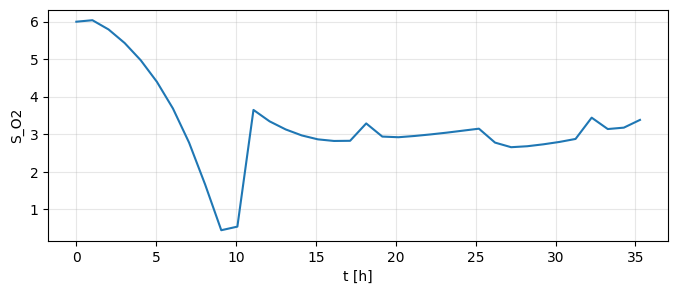

In [22]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(df_full["t_hours"], df_full["S_O2"])
ax.set_xlabel("t [h]")
ax.set_ylabel("S_O2")
ax.grid(True, alpha=0.3)
plt.show()

## Plots: particulate biomass

`X_ALG`, `X_AOB`, `X_NOB`, `X_H` vs simulation time (uses `df_full` from the configurable run above).

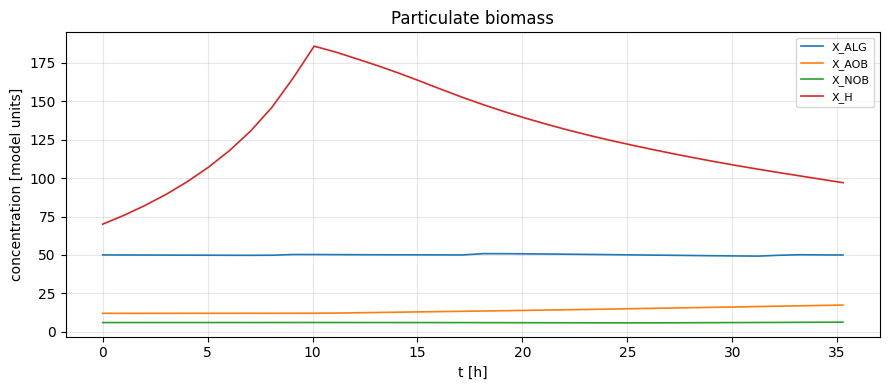

In [23]:
fig, ax = plt.subplots(figsize=(9, 4))
for col in ("X_ALG", "X_AOB", "X_NOB", "X_H"):
    ax.plot(df_full["t_hours"], df_full[col], label=col, linewidth=1.2)
ax.set_xlabel("t [h]")
ax.set_ylabel("concentration [model units]")
ax.set_title("Particulate biomass")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Plots: dissolved nitrogen species

`S_NH`, `S_NO2`, `S_NO3`, `S_N2` vs time (`df_full`).

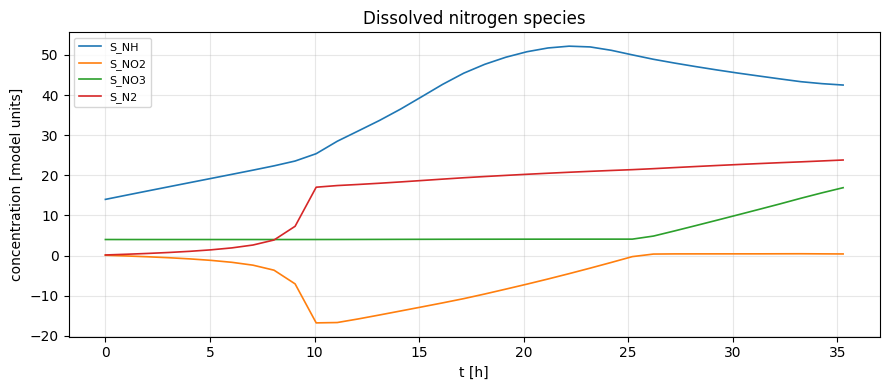

In [24]:
fig, ax = plt.subplots(figsize=(9, 4))
for col in ("S_NH", "S_NO2", "S_NO3", "S_N2"):
    ax.plot(df_full["t_hours"], df_full[col], label=col, linewidth=1.2)
ax.set_xlabel("t [h]")
ax.set_ylabel("concentration [model units]")
ax.set_title("Dissolved nitrogen species")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Plot: phosphate

Soluble phosphate `S_PO4` vs time (`df_full`).

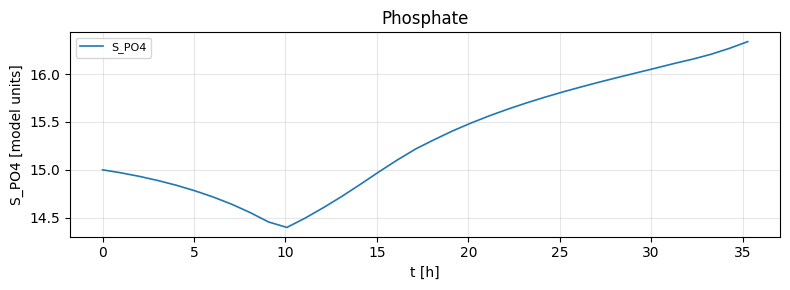

In [25]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(df_full["t_hours"], df_full["S_PO4"], color="C0", linewidth=1.2, label="S_PO4")
ax.set_xlabel("t [h]")
ax.set_ylabel("S_PO4 [model units]")
ax.set_title("Phosphate")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()